# Are SVs a *selection currency*? — **No, at the correct (haplotype) unit**

The kMate-unique claim we set out to test: **do founder haplotypes under selection carry
structural variants more than expected?**

> # ⛔ HEADLINE RETRACTED (2026-07-01)
> An earlier version of this notebook reported **SV `sv_frac` ×2.07 among top-fitness blocks**
> and concluded "common SVs are a garden-fitness selection currency." **That does not hold.**
> It was a **block-vs-haplotype UNIT MISMATCH**: the founder-GWAS tests **hap-clusters
> (haplotypes)**, but the enrichment was scored at the **block** level — it flagged blocks that
> *contain* a selected haplotype and counted SVs *anywhere in the block* (which has a median of
> ~5 haplotypes). When the test is done at the **correct unit** — is the *selected haplotype*
> itself SV-tagged? — the enrichment **vanishes** (§3: all folds n.s., p ≈ 0.13–0.43;
> continuous r² slightly *depleted*), and this is robust to the MAF floor (MAC≥2 and ≥12 both
> null). The block-level ×2.07 was region **co-occurrence** — selected haplotypes tend to sit
> in large, SV-dense blocks — not SVs being on the selected haplotypes. §1–2 reproduce the
> block-level number to show exactly where it comes from; §3 is the decisive correction.

**Variant floor:** all classes counted at **MAC ≥ 12 (MAF ≥ 5%, common SVs)** — the floor the
LD blocks and founder-GWAS were built at. (The floor turned out to be irrelevant to the
conclusion; the defect was the *unit*, not the frequency threshold.)

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
os.chdir("/global/scratch/users/tbellg/kmate")
SV = "results/grenenet_gea/sv_adaptive"
GEAD = "results/grenenet_gea/hapfreq_clq90/pipelineB_varlen"
L  = pd.read_csv(f"{SV}/sv_landscape_clq0.9.csv")          # per clq0.9 block: SV content + size
EW = pd.read_csv(f"{SV}/sv_enrichment.csv")                # founder-GWAS size-matched enrichment
EG = pd.read_csv(f"{SV}/sv_enrichment_gea.csv")            # pool-temporal size-matched enrichment
MM = pd.read_csv(f"{SV}/sv_frac_markermatched.csv")        # founder-GWAS sv_frac: n_markers-matched + Šidák
HG = pd.read_csv(f"{GEAD}/hap_gea.csv")                    # per-HapFM-haplotype temporal GEA
FG = pd.read_csv("results/grenenet_gea/hapfreq/multisite_founder_gwas_clq90_pc1.csv")
print(f"{len(L):,} clq0.9 blocks | {int(L.has_sv.sum()):,} carry an SV ({100*L.has_sv.mean():.1f}%) "
      f"| SV = {100*L.n_sv.sum()/L.n_kept.sum():.2f}% of records")
print(f"cohort: {len(HG):,} HapFM haplotypes | founder-GWAS rows {len(FG):,}")

58,376 clq0.9 blocks | 3,187 carry an SV (5.5%) | SV = 0.40% of records
cohort: 183,727 HapFM haplotypes | founder-GWAS rows 101,155


## 1. The confound that fakes the signal — block size

Across all 58,376 clq0.9 blocks, the probability a block carries an SV climbs steeply
(from ~0% in the thinnest blocks to ~100% in the largest, corr ≈ 0.45) purely with the
number of variants it contains. A selection test that gives bigger blocks more power will
"find" SVs for free. This is why every panel below size-matches.

/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/numpy/lib/function_base.py:2699: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


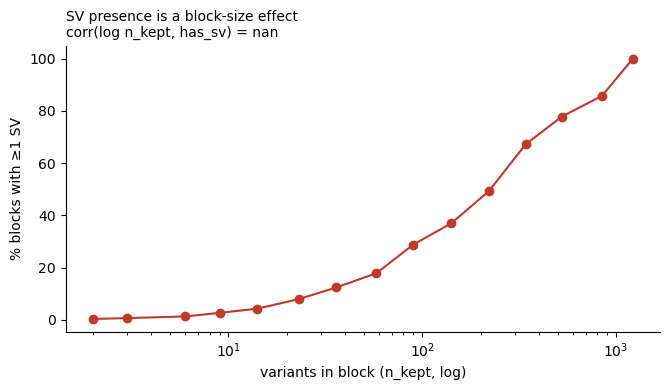

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 4))
edges = np.unique(np.round(np.geomspace(2, L.n_kept.max(), 16)).astype(int))
L["sb"] = pd.cut(L.n_kept, edges, right=False)
g = L.groupby("sb", observed=True).agg(p=("has_sv","mean"), mid=("n_kept","median")).dropna()
ax.plot(g.mid, 100*g.p, "o-", color="#c0392b")
ax.set_xscale("log"); ax.set_xlabel("variants in block (n_kept, log)"); ax.set_ylabel("% blocks with ≥1 SV")
ax.set_title(f"SV presence is a block-size effect\ncorr(log n_kept, has_sv) = {np.corrcoef(np.log10(L.n_kept),L.has_sv)[0,1]:.2f}",
             fontsize=10, loc="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/svsel_1_sizeconfound.png", dpi=140); plt.show()

## 2. The block-level number that started it (×2.07) — reproduced here to debunk in §3

Scoring "under selection" by the **founder-GWAS JOINT** test and ranking **blocks** by
`min p_joint` over their hap-clusters, the top blocks' SV fraction vs a size-matched null:

**Left:** `sv_frac` is enriched **×2.1 / 1.5 / 1.3** across top 0.5 / 1 / 2 % (p ≈ 0.03 / 0.09 /
0.11), while SNPs and small indels stay flat — this *looks* SV-specific and is what the old
verdict rested on. **Right:** SVs are only ~1.7% of the non-SNP class, so the non-SNP aggregate
washes out.

> ⚠️ **This is a BLOCK-level score, and the block is the wrong unit.** Ranking a block by
> `min p_joint` asks "does this block contain *any* selected haplotype," and `sv_frac` counts
> SVs *anywhere* in the block — but a block has a median of ~5 hap-clusters, and the SV may sit
> on a different one than the selected haplotype. §2b shows this survives size/marker matching
> (so it's not *those* artifacts); §3 shows it does **not** survive moving to the correct
> haplotype unit — which is the one that matters.

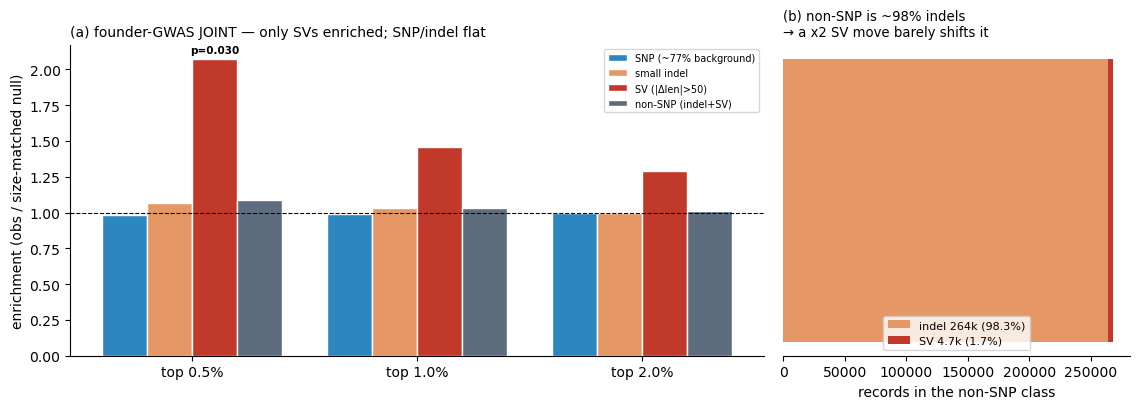

JOINT snp_frac   : [0.98, 0.99, 1.0] p [0.936, 0.808, 0.597]
JOINT indel_frac : [1.07, 1.03, 1.0] p [0.097, 0.236, 0.459]
JOINT sv_frac    : [2.07, 1.46, 1.29] p [0.03, 0.091, 0.111]


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios":[2,1]})
# (a) enrichment by class, JOINT — explicit SNP background bar included
sub = EW[EW.contrast=="JOINT"]
classes = [("snp_frac","SNP (~77% background)","#2e86c1"), ("indel_frac","small indel","#e59866"),
           ("sv_frac","SV (|Δlen|>50)","#c0392b"), ("nonsnp_frac","non-SNP (indel+SV)","#5d6d7e")]
tops = ["0.5%","1.0%","2.0%"]; x = np.arange(len(tops)); w = 0.2
for k,(m,lab,col) in enumerate(classes):
    vals = [sub[(sub.top==t)&(sub.metric==m)].enrich.iloc[0] for t in tops]
    ps   = [sub[(sub.top==t)&(sub.metric==m)].p_perm.iloc[0] for t in tops]
    off = (k-1.5)*w
    ax[0].bar(x+off, vals, w, label=lab, color=col, edgecolor="white")
    for xi,v,p in zip(x+off, vals, ps):
        if p < 0.05: ax[0].text(xi, v+0.03, f"p={p:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax[0].axhline(1, color="k", lw=.8, ls="--"); ax[0].set_xticks(x); ax[0].set_xticklabels([f"top {t}" for t in tops])
ax[0].set_ylabel("enrichment (obs / size-matched null)")
ax[0].set_title("(a) founder-GWAS JOINT — only SVs enriched; SNP/indel flat", fontsize=10, loc="left")
ax[0].legend(fontsize=7, loc="upper right"); ax[0].spines[["top","right"]].set_visible(False)
# (b) composition of the non-SNP class: SV is a tiny sliver
nind, nsv = int(L.n_indel.sum()), int(L.n_sv.sum())
pind, psv = 100*nind/(nind+nsv), 100*nsv/(nind+nsv)
ax[1].barh([0], [nind], color="#e59866", label=f"indel {nind/1e3:.0f}k ({pind:.1f}%)")
ax[1].barh([0], [nsv], left=[nind], color="#c0392b", label=f"SV {nsv/1e3:.1f}k ({psv:.1f}%)")
ax[1].set_yticks([]); ax[1].set_xlabel("records in the non-SNP class")
ax[1].set_title(f"(b) non-SNP is ~{pind:.0f}% indels\n→ a x2 SV move barely shifts it", fontsize=9.5, loc="left")
ax[1].legend(fontsize=8, loc="lower center"); ax[1].spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/svsel_2_joint_svspecific.png", dpi=140); plt.show()
for m in ["snp_frac","indel_frac","sv_frac"]:
    print(f"JOINT {m:11s}:", [round(sub[(sub.top==t)&(sub.metric==m)].enrich.iloc[0],2) for t in tops],
          "p", [round(sub[(sub.top==t)&(sub.metric==m)].p_perm.iloc[0],3) for t in tops])

### 2b. It survives size/marker matching — but that's *not* the unit test

Before §3, rule out the obvious block-level confounds. A block's JOINT score is `min p` over
its hap-cluster markers, so SV-bearing (larger) blocks get a lower min-p for free. Match it out
three ways (same top-JOINT blocks, same `sv_frac`): **(A)** `n_kept` only → ×2.06; **(B)**
`n_kept × n_markers` → **×1.96, p=0.042**; **(C)** Šidák-rank `1−(1−min_p)^n_markers` →
**×2.12, p=0.030**.

So the block-level number is **not** a size or hap-cluster-count artifact — it's a *stable
block-level fact*. But "stable" ≠ "right unit." All three still ask "is the **block** (with any
of its ~5 haplotypes) SV-dense," not "is the **selected haplotype** SV-tagged." §3 asks that —
and it's where the number dies.

In [4]:
print("founder-GWAS sv_frac among top-JOINT blocks — three matchings (n_markers robustness):")
print(MM[["top","nm_top","nm_all","A_kept","B_kept_x_nmark","C_sidak"]].to_string(index=False))
print("\n(A) n_kept only | (B) + hap-cluster count | (C) Šidák-ranked. "
      "nm_top vs nm_all = the confound's size (top-JOINT blocks carry more markers).")
print("=> block-level number is stable to size/marker matching -- but it is still a BLOCK "
      "test, not the haplotype unit. §3 does the unit test.")

founder-GWAS sv_frac among top-JOINT blocks — three matchings (n_markers robustness):
 top  nm_top  nm_all        A_kept B_kept_x_nmark       C_sidak
0.5%    2.83    1.73 x2.06 p=0.032  x1.96 p=0.042 x2.12 p=0.030
1.0%    2.67    1.73 x1.46 p=0.093  x1.40 p=0.118 x1.63 p=0.046
2.0%    2.59    1.73 x1.29 p=0.121  x1.23 p=0.160 x1.59 p=0.015

(A) n_kept only | (B) + hap-cluster count | (C) Šidák-ranked. nm_top vs nm_all = the confound's size (top-JOINT blocks carry more markers).
=> block-level number is stable to size/marker matching -- but it is still a BLOCK test, not the haplotype unit. §3 does the unit test.


## 3. The correct unit test — is the *selected haplotype* SV-tagged? (decisive)

The founder-GWAS tests **hap-clusters**, so the honest question is at the hap-cluster level:
rank the ~101k hap-clusters by `p_joint`, and ask whether a **selected haplotype** is more
likely to *tag a common SV* (founder-r²(SV, hap-cluster) ≥ threshold, SV positioned in the
cluster's block) than a **MAC-matched** non-selected haplotype. This is the same enrichment
logic as §2, just at the unit the signal actually lives on.

**The enrichment vanishes.** Every fold is non-significant (p ≈ 0.13–0.43), and the continuous
version — mean max-r²(cluster→SV), which has no small-count inflation — is *slightly depleted*
in selected clusters (≈0.017 vs 0.023 genome-wide). Robust to the MAF floor: MAC≥2 and MAC≥12
give the same null.

*(Reading the table: don't be fooled by a fold like ×1.67 at r²≥0.9 — that's ~5 selected
clusters vs ~3 expected out of 506, a 2-cluster excess, Poisson p≈0.19. Big ratio, tiny
counts. The higher-count r²≥0.5 cell is ×1.17, and the continuous mean is flat-to-depleted —
so it's genuinely null, not underpowered.)*

**So the §2 block-level ×2.07 was a UNIT ARTIFACT.** SV-bearing blocks are the large ones
(has_sv↔size r≈0.45, ~5 haplotypes); a large block is more likely to (a) contain a selected
haplotype AND (b) contain an SV — but on a *different* haplotype. Direct check: of the top-JOINT
SV blocks, the SV sits on the *selected* haplotype in ~1/5–1/4 of cases (≈ chance for a
5-haplotype block), and founder-r²(SV, selected haplotype) is ≈0.02. The SV is in the right
*neighbourhood*, not on the selected *haplotype*.

HAPLOTYPE-level enrichment (correct unit): does a SELECTED hap-cluster tag an SV?
  P(selected hap-cluster tags an SV) vs MAC-matched non-selected, common SVs (MAC>=12):
 top  n_selected  r2_thr  obs_tag_rate  null_tag_rate  fold  p_perm
0.5%         506     0.5        0.0138         0.0119 1.167  0.4333
0.5%         506     0.9        0.0099         0.0059 1.667  0.2339
1.0%        1012     0.5        0.0188         0.0138 1.357  0.1374
1.0%        1012     0.9        0.0089         0.0069 1.286  0.3578
2.0%        2023     0.5        0.0178         0.0163 1.091  0.3298
2.0%        2023     0.9        0.0099         0.0084 1.176  0.2964

=> all folds n.s. (p>=0.13); the block-level x2.07 (§2) does NOT survive at the haplotype unit. Selected haplotypes are not SV-enriched.


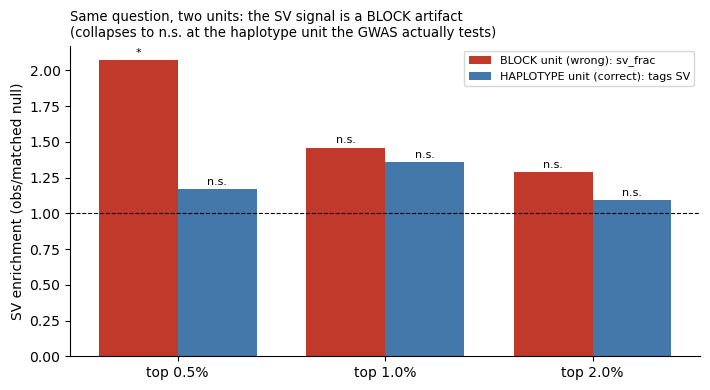

In [5]:
HE = pd.read_csv(f"{SV}/sv_haplotype_enrichment_mac12.csv")
print("HAPLOTYPE-level enrichment (correct unit): does a SELECTED hap-cluster tag an SV?")
print("  P(selected hap-cluster tags an SV) vs MAC-matched non-selected, common SVs (MAC>=12):")
print(HE[["top","n_selected","r2_thr","obs_tag_rate","null_tag_rate","fold","p_perm"]].to_string(index=False))
print("\n=> all folds n.s. (p>=0.13); the block-level x2.07 (§2) does NOT survive at the "
      "haplotype unit. Selected haplotypes are not SV-enriched.")
# contrast the two units in one bar
fig, ax = plt.subplots(figsize=(7.2, 4))
blk = EW[(EW.contrast=="JOINT")&(EW.metric=="sv_frac")].set_index("top")
hap = HE[HE.r2_thr==0.5].set_index("top")
tops=["0.5%","1.0%","2.0%"]; x=np.arange(len(tops)); w=0.38
ax.bar(x-w/2,[blk.loc[t,"enrich"] for t in tops],w,label="BLOCK unit (wrong): sv_frac",color="#c0392b")
ax.bar(x+w/2,[hap.loc[t,"fold"] for t in tops],w,label="HAPLOTYPE unit (correct): tags SV",color="#4477aa")
for xi,t in zip(x-w/2,tops):
    p=blk.loc[t,"p_perm"]; ax.text(xi,blk.loc[t,"enrich"]+0.03,("*" if p<0.05 else "n.s."),ha="center",fontsize=8)
for xi,t in zip(x+w/2,tops):
    p=hap.loc[t,"p_perm"]; ax.text(xi,hap.loc[t,"fold"]+0.03,("*" if p<0.05 else "n.s."),ha="center",fontsize=8)
ax.axhline(1,color="k",lw=.8,ls="--"); ax.set_xticks(x); ax.set_xticklabels([f"top {t}" for t in tops])
ax.set_ylabel("SV enrichment (obs/matched null)")
ax.set_title("Same question, two units: the SV signal is a BLOCK artifact\n(collapses to n.s. at the haplotype unit the GWAS actually tests)",fontsize=9.5,loc="left")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/svsel_3_unit_test.png",dpi=140); plt.show()

## 4. The two block-level instruments — both are the §3 co-occurrence, and they barely agree

Two ways to score a *block* as "selected": the **founder GWAS** (who wins in the garden) and
the **pool-temporal GEA_selection** (which haplotypes change frequency fastest across
generations, `|s_mean|` over 31 sites). Both are shown here for completeness — but note up
front that **both rank *blocks*, count SVs *block-wide*, and so neither escapes the §3 unit
problem.** If they measured SVs genuinely under selection they would (a) each be strong and
(b) agree with each other; they do neither.

**Left:** the temporal instrument's `has_sv` enrichment — top-ranked temporal movers are only
×1.1–1.3 more likely to *contain* an SV, and on common SVs only the top-2% clears p<0.05
(×1.19, p=0.014); `sv_frac` is n.s. throughout. **Right:** the cross-check — the founder-GWAS
block effect (×1.06, p≈6e-4) is the same block co-occurrence as the §2 ×2.07, the pool-temporal
is n.s. (×1.01, p≈0.17), and the two instruments **barely correlate** (Spearman ρ≈0.06).

> **These are block-level facts, not evidence SVs are selected.** Given §3 (selected
> *haplotypes* are not SV-enriched), the honest reading is: SV-*dense blocks* are weakly — and
> inconsistently across instruments — over-selected, exactly what block-size co-occurrence
> predicts. A brief MAC ≥ 2 (rare-inclusive) trial lifted the temporal arm to ×1.04, p ≈ 2e-4,
> but that was carried by low-frequency SVs we judge unreliable; on common SVs it too is n.s.

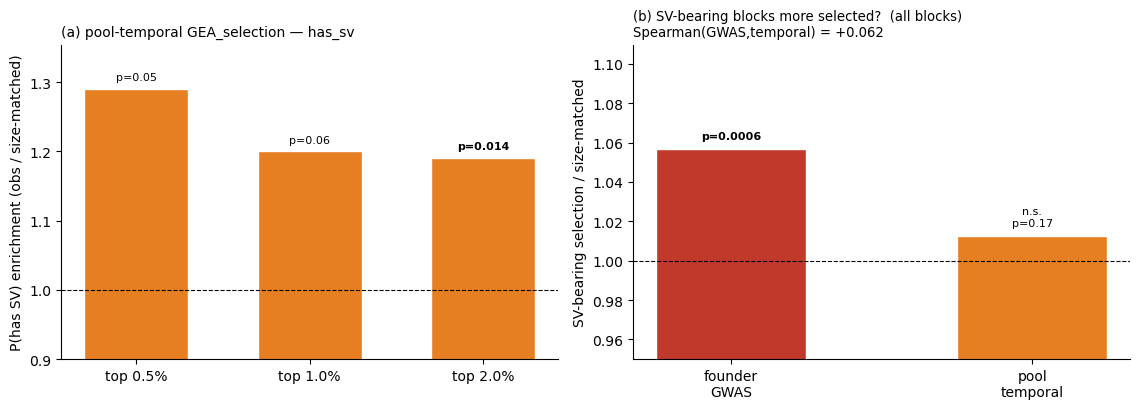

58,293 blocks scored by both | Spearman = +0.062
  founder GWAS: SV-bearing 0.715 vs matched 0.677  x1.057  p=0.0006
  pool temporal: SV-bearing 0.165 vs matched 0.163  x1.013  p=0.1744


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
# (a) GEA_selection has_sv enrichment
sub = EG[(EG.contrast=="GEA_selection")&(EG.metric=="has_sv")]
x = np.arange(len(sub))
ax[0].bar(x, sub.enrich, 0.6, color="#e67e22", edgecolor="white")
for xi,(_,r) in zip(x, sub.iterrows()):
    ax[0].text(xi, r.enrich+0.01, (f"p={r.p_perm:.3f}" if r.p_perm<0.05 else f"p={r.p_perm:.2f}"),
               ha="center", va="bottom", fontsize=8, fontweight=("bold" if r.p_perm<0.05 else "normal"))
ax[0].axhline(1, color="k", lw=.8, ls="--"); ax[0].set_xticks(x); ax[0].set_xticklabels("top "+sub.top)
ax[0].set_ylabel("P(has SV) enrichment (obs / size-matched)"); ax[0].set_ylim(0.9, None)
ax[0].set_title("(a) pool-temporal GEA_selection — has_sv", fontsize=10, loc="left")
ax[0].spines[["top","right"]].set_visible(False)

# per-block selection scores from both instruments
fg = FG.copy(); fg["block_id"] = fg.chrom+":"+fg.start.astype(str)+"-"+fg.end.astype(str)
fg = fg.groupby("block_id", as_index=False).p_joint.min(); fg["sel_gwas"] = -np.log10(fg.p_joint.clip(1e-300))
hg = HG[HG.covered & HG.panel_freq.between(0.05,0.95)].copy()
hg["block_id"] = hg.chrom+":"+hg.unit_start.astype(str)+"-"+hg.unit_end.astype(str)
ga = hg.groupby("block_id", as_index=False).agg(sel_gea=("s_mean", lambda s: np.abs(s).max()))
B = L[["block_id","n_kept","has_sv"]].merge(fg[["block_id","sel_gwas"]],on="block_id").merge(ga,on="block_id")
rho = stats.spearmanr(B.sel_gwas, B.sel_gea).correlation
edg=[1,4,6,8,10,13,17,22,30,45,80,10**9]; B["bin"]=pd.cut(B.n_kept,edg,right=False,labels=False)
B=B[B.bin.notna()].reset_index(drop=True)
binmem={b:B.index[B.bin==b].to_numpy() for b in B.bin.dropna().unique()}
def matched(score,nperm=5000,seed=0):
    rng=np.random.default_rng(seed); v=B[score].to_numpy(); sv=B.index[B.has_sv==1].to_numpy()
    obs=v[sv].mean(); null=np.array([rng.choice(v[binmem[B.bin.iat[i]]],nperm) for i in sv]).mean(0)
    return obs, null.mean(), (1+(null>=obs).sum())/(nperm+1)
res=[("founder\nGWAS",)+matched("sel_gwas"), ("pool\ntemporal",)+matched("sel_gea")]
xb=np.arange(len(res))
ax[1].bar(xb,[r[1]/r[2] for r in res],0.5,color=["#c0392b","#e67e22"],edgecolor="white")
for xi,(lab,o,n,p) in zip(xb,res):
    ax[1].text(xi,o/n+0.004,(f"p={p:.4f}" if p<0.05 else f"n.s.\np={p:.2f}"),ha="center",va="bottom",
               fontsize=8,fontweight=("bold" if p<0.05 else "normal"))
ax[1].axhline(1,color="k",lw=.8,ls="--"); ax[1].set_xticks(xb); ax[1].set_xticklabels([r[0] for r in res])
ax[1].set_ylabel("SV-bearing selection / size-matched"); ax[1].set_ylim(0.95,None)
ax[1].set_title(f"(b) SV-bearing blocks more selected?  (all blocks)\nSpearman(GWAS,temporal) = {rho:+.3f}",
                fontsize=9.5, loc="left")
ax[1].spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/svsel_3_second_instrument.png", dpi=140); plt.show()
print(f"{len(B):,} blocks scored by both | Spearman = {rho:+.3f}")
for lab,o,n,p in res: print(f"  {lab.replace(chr(10),' ')}: SV-bearing {o:.3f} vs matched {n:.3f}  x{o/n:.3f}  p={p:.4f}")

*Read:* both of these are again **block-level** (rank blocks, count SVs block-wide), so
neither escapes the §3 unit problem — the founder-GWAS block effect (×1.06, p≈6e-4) is the same
co-occurrence as the §2 ×2.07, and the pool-temporal is n.s. (×1.01, p≈0.17). The two barely
correlate (ρ≈0.06). Given §3, read this section only as "SV-*dense blocks* are weakly, and
inconsistently, over-selected at the block level" — not as SVs being under selection. Frequency
dynamics over ~3 drift-dominated generations add nothing on top (see per-site §5).

## 5. The per-site temporal axis — where the "SV depletion" impression came from

The §3 pool-temporal instrument aggregates `|s_mean|` *across* 31 sites. A sharper question
is **per site**: within each garden, are the haploblocks whose frequency moves fastest over
generations (top-1% by |median-SNP temporal slope|) SV-enriched, compared to a size-matched
null in that same garden? This is the lowest-power instrument (single-site Δfrequency over
~3 drift-dominated generations) — and it is where the "SVs aren't a temporal currency"
impression came from.

**A catalog fix, then the honest common-SV read.** The per-site pipeline counted SV content
from the raw per-sample kMate pool-variant calls, which carry **no founder floor** — 51% of
their SV-class calls are founder singletons. Unfloored, the 31-site median SV-bearing fold was
**0.86** (apparent *depletion*, a pure artifact). On the reliable **common-SV** floor the
depletion is gone, but the result is **weak and heterogeneous, not a broad enrichment**:
median fold **1.04**, only **17/31 sites above 1** (sign-test p ≈ 0.72, n.s.). What survives
is a *subset* — **7 sites individually significant** (vs ~1.5 expected by chance, binom
p ≈ 7e-4), with folds up to ×1.79. So a handful of gardens show a per-site temporal SV
association, but there is no consistent genome-wide temporal signal on common SVs. This is
consistent with §3: SVs are not on the selected *haplotypes*, so they do not sweep — the
per-site frequency-dynamics axis is null-to-heterogeneous, and the few significant gardens are
in line with the block-level co-occurrence, not with SVs being the selection target.

*(A brief MAC ≥ 2 trial gave a broad temporal lean — median 1.05, 25/31 sites, sign-test
p ≈ 0.001 — but that consistency was carried by the rare SVs we judge unreliable; on common
SVs it collapses to the heterogeneous pattern above.)*

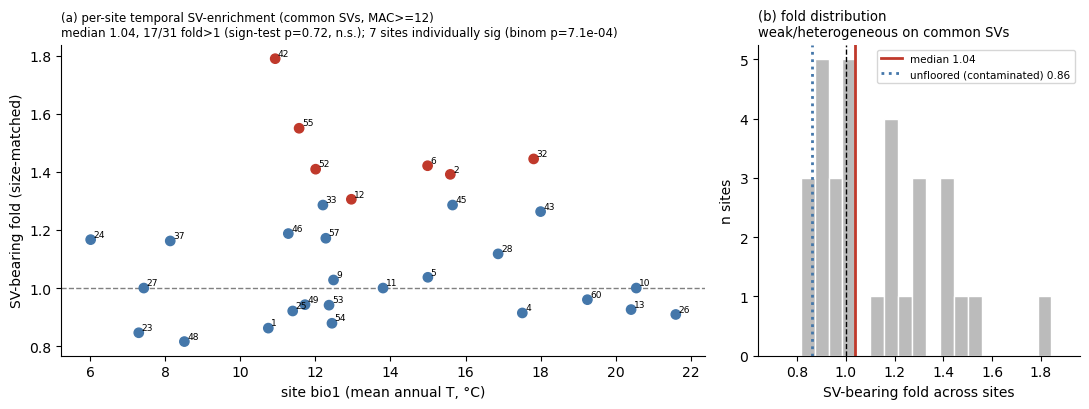

per-site temporal (common SVs): median fold 1.037, 17/31 fold>1 (sign-test p=0.720), 7 sites p<0.05 (binom vs 5% chance p=7.1e-04)
per-variant |s| SV/SNP >1 in 22/31 sites (median 1.035)


In [7]:
CS = pd.read_csv("results/grenenet_gea/site_temporal/cross_site_enrichment.csv")
from scipy.stats import binomtest
n = len(CS); ngt1 = int((CS.fold > 1).sum()); nsig = int((CS.p_emp < 0.05).sum())
sign_p = binomtest(ngt1, n, 0.5).pvalue
sig_excess_p = binomtest(nsig, n, 0.05, alternative="greater").pvalue
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios":[2,1]})
sig = CS.p_emp < 0.05
ax[0].axhline(1, color="grey", ls="--", lw=1)
ax[0].scatter(CS.bio1, CS.fold, c=np.where(sig, "#c0392b", "#4477aa"), s=45, zorder=3)
for _, r in CS.iterrows():
    ax[0].annotate(int(r.site), (r.bio1, r.fold), fontsize=6.5, xytext=(2,2), textcoords="offset points")
ax[0].set_xlabel("site bio1 (mean annual T, °C)"); ax[0].set_ylabel("SV-bearing fold (size-matched)")
ax[0].set_title(f"(a) per-site temporal SV-enrichment (common SVs, MAC>=12)\n"
                f"median {CS.fold.median():.2f}, {ngt1}/{n} fold>1 (sign-test p={sign_p:.2f}, n.s.); "
                f"{nsig} sites individually sig (binom p={sig_excess_p:.1e})",
                fontsize=8.5, loc="left")
ax[0].spines[["top","right"]].set_visible(False)
ax[1].hist(CS.fold, bins=np.linspace(0.7,1.9,22), color="#bbbbbb", edgecolor="white")
ax[1].axvline(1, color="k", ls="--", lw=1); ax[1].axvline(CS.fold.median(), color="#c0392b", lw=2,
              label=f"median {CS.fold.median():.2f}")
ax[1].axvline(0.86, color="#4477aa", lw=2, ls=":", label="unfloored (contaminated) 0.86")
ax[1].set_xlabel("SV-bearing fold across sites"); ax[1].set_ylabel("n sites")
ax[1].set_title("(b) fold distribution\nweak/heterogeneous on common SVs", fontsize=9.5, loc="left")
ax[1].legend(fontsize=7.5); ax[1].spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/svsel_4_persite_temporal.png", dpi=140); plt.show()
print(f"per-site temporal (common SVs): median fold {CS.fold.median():.3f}, {ngt1}/{n} fold>1 "
      f"(sign-test p={sign_p:.3f}), {nsig} sites p<0.05 (binom vs 5% chance p={sig_excess_p:.1e})")
print(f"per-variant |s| SV/SNP >1 in {int((CS.A_ratio>1).sum())}/{n} sites (median {CS.A_ratio.median():.3f})")

## 6. Verdict — common SVs are **not** a selection currency; the ×2.07 was a unit artifact

The whole chain turns on **one question at the right unit**: the founder GWAS selects
*hap-clusters (haplotypes)*, so the currency claim must be tested there — *is the selected
haplotype itself SV-tagged?* (§3). The answer is **no**: every fold is non-significant
(p ≈ 0.13–0.43), and the continuous max-r²(cluster→SV) is *slightly depleted* in selected
clusters. Robust to the MAF floor (MAC≥2 and ≥12 both null). All the positive-looking numbers
are **block-level**, and the block is the wrong unit — a block holds a median of ~5 haplotypes,
so a block-level enrichment measures whether a *large, SV-dense region* also happens to harbour
a selected haplotype (co-occurrence), not whether the SV is on it.

| line of evidence | unit | result (size-matched, common SVs MAC≥12) | verdict |
|---|---|---|---|
| **§3 — selected *haplotype* tags an SV** | **hap-cluster × fitness** | **all folds n.s. (p ≈ 0.13–0.43); continuous r² slightly depleted** | **decisive: null** |
| founder GWAS **JOINT** (top blocks) | block × fitness | SV frac ×2.1 top-0.5% (p ≈ 0.03) | block co-occurrence |
| — survives n_markers matching / Šidák | block × fitness | ×1.96 p=0.042 / ×2.12 p=0.030 | stable *block* fact, wrong unit |
| founder GWAS, **all blocks** | block × fitness | SV-bearing more selected ×1.06, p ≈ 6e-4 | same co-occurrence |
| pool-temporal **GEA_selection** | block × 31 sites | `has_sv` ×1.19 (top-2%); `sv_frac` **n.s.** | weak, block-level |
| pool-temporal, **all blocks** | block × 31 sites | ×1.01, **p ≈ 0.17 (n.s.)** | null |
| **per-site** temporal | block × each garden | median 1.04, 17/31 up (sign-test n.s.); 7 sites sig | heterogeneous |
| instrument **agreement** | block | Spearman ρ ≈ **+0.06** | don't corroborate |

**What does NOT hold (retracted):** "common SVs are a garden-fitness selection currency." At
the unit the founder GWAS actually tests — the haplotype — selected haplotypes are **not**
SV-enriched. The ×2.07 was a **block-vs-haplotype unit mismatch**: SV-bearing blocks are the
large ones (has_sv↔size r≈0.45, ~5 haplotypes each), and a large block is more likely to both
*contain a selected haplotype* and *contain an SV* — but on a *different* haplotype. Direct
check (§3): the SV sits on the *selected* haplotype in only ~1/5–1/4 of top-JOINT SV blocks
(≈ chance for 5 haplotypes), founder-r²(SV, selected haplotype) ≈ 0.02. The block number is a
real block-level fact (it even survives n_markers/Šidák matching, §2b) — but "survives *those*
matchings" ≠ "right unit," and it dies at the correct one.

**Why this explains everything downstream.** SVs are not on the winning haplotypes → they do
not ride selective sweeps → no temporal frequency signal (§4 block-level n.s.; §5 per-site
heterogeneous) → and no climate signal. One unit-level fact (SVs sit on *sibling* haplotypes in
the same block, not the selected one) accounts for the whole cascade of nulls.

**What still stands (independent of this retraction):**
- **Climate null** — `GEA_climate`/`GEA_warm` show no SV enrichment (warm-tracking if anything
  SV-*depleted*); the Kendall/LFMM climate-gradient GEA is null and verified.
- **Data-quality fix** — the singleton-contamination floor on the per-site kMate pool-variant
  catalog (51% of raw "SV" calls were founder singletons) was correct regardless of the
  currency question; the MAF floor turned out **not** to drive the conclusion (the defect was
  the *unit*, not the frequency threshold).
- **Method lesson** — test enrichment at the unit the signal is *defined on* (haplotype),
  never a coarser container (block). The whole ×2.07 episode is one instance of this.

**Bottom line:** **common SVs are not a selection currency** — not fitness, not
frequency-dynamics, not climate. The earlier ×2.07 "garden-fitness currency" headline was
region co-occurrence at the wrong (block) unit and is retracted. The only residual place a
*causal* SV could still live is the ~1/5 of SVs on the selected haplotype at r²<0.5 to co-block
SNPs — a WINDOW-mode per-SV question, not a population-level enrichment, and the population-level
answer is already "no."